# Task 2 (FMA-small) - GNN Genre Classification vs. CNN Baseline

Single-label genre classification on FMA-small (8,000 tracks, 8 balanced genres), as required by the Task 2 spec.

Two models are trained on identical splits for a like-for-like comparison:
1. **GNN** (GAT / GraphSAGE) over MFCC+chroma segment graphs — audio-only node features
2. **CNN baseline** over mel-spectrograms — the reference comparison required by the spec



In [1]:
# 1. Install and import dependencies
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("torch_geometric") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", "torch-geometric"]
    )
if importlib.util.find_spec("librosa") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "librosa"])

import json
import random
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, SAGEConv, global_mean_pool
from tqdm.auto import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.8 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
CUDA available: True


In [2]:
# 2. Configure Kaggle paths, audio-processing, and training parameters
SEED = 42
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 5e-4
WARMUP_EPOCHS = 3
WEIGHT_DECAY = 1e-3
EARLY_STOPPING_PATIENCE = 8
NUM_WORKERS = 2

# Audio/graph construction. Shorter segments give the GNN more nodes to reason over.
AUDIO_SR = 22050
SEGMENT_DURATION = 3.0
N_MFCC = 20
N_FFT = 2048
HOP_LENGTH = 512
SIMILARITY_NEIGHBORS = 2  # kNN edges per node instead of a global similarity threshold
CLIP_DURATION_LIMIT = 30.0  # FMA clips are ~30s previews

# Mel-spectrogram settings for the CNN baseline (full 30s audio = 640 frames at hop=1024).
N_MELS = 128
MEL_HOP_LENGTH = 1024
MEL_FRAMES = 640
CNN_CROP_FRAMES = 384  # Random crop for training data augmentation, multi-crop for testing

# GraphSAGE encoder matching Algorithm 2 in the project specification.
GNN_CONFIG = {
    "type": "GraphSAGE",
    "hidden_dim": 128,
    "num_layers": 2,
    "dropout": 0.5,
    "heads": 4,
}

CNN_CONFIG = {
    "channels": [32, 64, 128, 256],
    "dropout": 0.3,
}

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
OUTPUT_DIR = Path("/kaggle/working/task2_fma_small_results")
# Versioned to v3 for higher-order statistics (Tonnetz + min/max envelopes).
GRAPH_DIR = OUTPUT_DIR / "graphs_v3"
MEL_DIR = OUTPUT_DIR / "mels_v3"
for directory in (OUTPUT_DIR, GRAPH_DIR, MEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# A previous session's preprocessing output, if it was saved and reattached as an input dataset.
CACHED_GRAPH_DIR = next(KAGGLE_INPUT_ROOT.glob("**/graphs_v3"), None)
CACHED_MEL_DIR = next(KAGGLE_INPUT_ROOT.glob("**/mels_v3"), None)


def cached_or_working(filename, cached_dir, working_dir):
    if cached_dir is not None and (cached_dir / filename).exists():
        return cached_dir / filename
    return working_dir / filename


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Device: {DEVICE}")
print(f"Kaggle input root: {KAGGLE_INPUT_ROOT}")
print(f"Outputs: {OUTPUT_DIR}")
print(f"Cached graphs: {CACHED_GRAPH_DIR}")
print(f"Cached mels:   {CACHED_MEL_DIR}")

Device: cuda
Kaggle input root: /kaggle/input
Outputs: /kaggle/working/task2_fma_small_results
Cached graphs: None
Cached mels:   None


In [3]:
# 3. Locate dataset files by searching all attached Kaggle inputs (dataset mount
# folder names and internal nesting both vary, so don't hardcode either).
def find_first(root, name):
    matches = list(root.rglob(name))
    if not matches:
        available = "\n".join(f"- {p}" for p in sorted(root.glob("*")))
        raise FileNotFoundError(
            f"Could not find '{name}' anywhere under {root}.\n"
            f"Attached Kaggle inputs:\n{available}\n"
            "Make sure the FMA dataset is added to this notebook's inputs."
        )
    return matches[0]


TRACKS_CSV_PATH = find_first(KAGGLE_INPUT_ROOT, "tracks.csv")

# The audio folder that directly contains 000, 001, ... three-digit subfolders
# (may be nested one extra level as fma_medium/fma_medium/000/...).
AUDIO_DIR = find_first(KAGGLE_INPUT_ROOT, "fma_medium")
while not any(child.is_dir() and len(child.name) == 3 for child in AUDIO_DIR.iterdir()):
    nested = [child for child in AUDIO_DIR.iterdir() if child.is_dir()]
    if len(nested) != 1:
        raise FileNotFoundError(f"Could not locate three-digit genre subfolders under {AUDIO_DIR}")
    AUDIO_DIR = nested[0]

print(f"Resolved tracks.csv: {TRACKS_CSV_PATH}")
print(f"Resolved audio dir: {AUDIO_DIR}")

tracks = pd.read_csv(TRACKS_CSV_PATH, index_col=0, header=[0, 1])
subset_mask = tracks[("set", "subset")] == "small"
genre_top = tracks[("track", "genre_top")]
split_column = tracks[("set", "split")]

metadata = pd.DataFrame(
    {
        "genre_top": genre_top[subset_mask],
        "split": split_column[subset_mask],
    }
).dropna(subset=["genre_top"])

class_names = sorted(metadata["genre_top"].unique().tolist())
class_to_index = {name: index for index, name in enumerate(class_names)}
NUM_CLASSES = len(class_names)

CLASS_NAMES_PATH = OUTPUT_DIR / "fma_class_names.json"
with CLASS_NAMES_PATH.open("w", encoding="utf-8") as file:
    json.dump(class_names, file, indent=2)

print(f"Tracks with usable genre label: {len(metadata):,}")
print(f"Classes ({NUM_CLASSES}): {class_names}")
print(metadata["split"].value_counts())


Resolved tracks.csv: /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata/tracks.csv
Resolved audio dir: /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_medium/fma_medium
Tracks with usable genre label: 8,000
Classes (8): ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']
split
training      6400
validation     800
test           800
Name: count, dtype: int64


In [4]:
# 4. Audio segmentation + segment-graph construction (ported from src/audio_features.py
# and src/graph_builder.py so this notebook is self-contained on Kaggle)
def track_id_to_path(track_id, audio_dir):
    padded = f"{int(track_id):06d}"
    return audio_dir / padded[:3] / f"{padded}.mp3"


def segment_descriptor(chunk, sr, n_mfcc, n_fft, hop_length):
    """Rich multi-statistic descriptor per segment (mean, std, min, max) capturing
    timbral, harmonic (chroma/tonnetz), and dynamic range across time."""
    mfcc = librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    delta = librosa.feature.delta(mfcc)
    chroma = librosa.feature.chroma_stft(y=chunk, sr=sr, n_fft=n_fft, hop_length=hop_length)
    tonnetz = librosa.feature.tonnetz(chroma=chroma)
    contrast = librosa.feature.spectral_contrast(y=chunk, sr=sr, n_fft=n_fft, hop_length=hop_length)
    centroid = librosa.feature.spectral_centroid(y=chunk, sr=sr, n_fft=n_fft, hop_length=hop_length)
    rolloff = librosa.feature.spectral_rolloff(y=chunk, sr=sr, n_fft=n_fft, hop_length=hop_length)
    zcr = librosa.feature.zero_crossing_rate(chunk, hop_length=hop_length)
    rms = librosa.feature.rms(y=chunk, hop_length=hop_length)

    # Multi-statistic aggregation (mean, std, min, max) for key timbral and energy features
    parts = [
        mfcc.mean(axis=1), mfcc.std(axis=1), mfcc.min(axis=1), mfcc.max(axis=1),
        delta.mean(axis=1), delta.std(axis=1),
        chroma.mean(axis=1), chroma.std(axis=1),
        tonnetz.mean(axis=1), tonnetz.std(axis=1), tonnetz.min(axis=1), tonnetz.max(axis=1),
        contrast.mean(axis=1), contrast.std(axis=1),
        centroid.mean(axis=1), centroid.std(axis=1),
        rolloff.mean(axis=1), rolloff.std(axis=1),
        zcr.mean(axis=1), zcr.std(axis=1),
        rms.mean(axis=1), rms.std(axis=1), rms.max(axis=1),
    ]
    return torch.tensor(np.concatenate(parts), dtype=torch.float32)


def segment_waveform(y, sr, segment_duration, n_mfcc, n_fft, hop_length):
    segment_samples = int(segment_duration * sr)
    segments = []
    for start in range(0, len(y), segment_samples):
        end = start + segment_samples
        if end > len(y):
            break
        segments.append(segment_descriptor(y[start:end], sr, n_mfcc, n_fft, hop_length))
    return segments


def build_segment_graph(segment_features, num_neighbors):
    num_nodes = len(segment_features)
    if num_nodes == 0:
        return None
    x = torch.stack(segment_features)

    # Standardize across nodes before similarity: raw features are dominated by a few
    # large-magnitude dimensions (MFCC c0, rolloff), which drives cosine to ~1.0 for every
    # pair and yields a complete, uninformative graph.
    standardized = (x - x.mean(dim=0)) / x.std(dim=0).clamp_min(1e-6)
    normalized = F.normalize(standardized, p=2, dim=1)
    similarity = normalized @ normalized.t()
    similarity.fill_diagonal_(-float("inf"))
    for i in range(num_nodes):  # temporal neighbours are added explicitly below
        for j in (i - 1, i + 1):
            if 0 <= j < num_nodes:
                similarity[i, j] = -float("inf")

    edge_set = set()
    for i in range(num_nodes):
        if i + 1 < num_nodes:
            edge_set.update({(i, i + 1), (i + 1, i)})
        k = min(num_neighbors, int((similarity[i] > -float("inf")).sum()))
        if k > 0:
            for j in torch.topk(similarity[i], k=k).indices.tolist():
                edge_set.update({(i, j), (j, i)})

    edge_index = (
        torch.tensor(sorted(edge_set), dtype=torch.long).t().contiguous()
        if edge_set
        else torch.zeros((2, 0), dtype=torch.long)
    )
    return Data(x=x, edge_index=edge_index)


def extract_log_mel(y, sr, n_mels, n_fft, hop_length, num_frames):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    if log_mel.shape[1] >= num_frames:
        start = (log_mel.shape[1] - num_frames) // 2
        log_mel = log_mel[:, start:start + num_frames]
    else:
        log_mel = np.pad(log_mel, ((0, 0), (0, num_frames - log_mel.shape[1])), constant_values=log_mel.min())
    return log_mel.astype(np.float16)


# 5. Build graphs and mel-spectrograms from a single audio decode pass (resumable)
processed_records = []
failed_count = 0

for track_id, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Preprocessing"):
    graph_path = cached_or_working(f"graph_{track_id}.pt", CACHED_GRAPH_DIR, GRAPH_DIR)
    mel_path = cached_or_working(f"mel_{track_id}.npy", CACHED_MEL_DIR, MEL_DIR)
    if graph_path.exists() and mel_path.exists():
        processed_records.append((track_id, row["genre_top"], row["split"]))
        continue

    audio_path = track_id_to_path(track_id, AUDIO_DIR)
    if not audio_path.exists():
        failed_count += 1
        continue

    try:
        waveform, _ = librosa.load(audio_path, sr=AUDIO_SR, duration=CLIP_DURATION_LIMIT)
        segments = segment_waveform(waveform, AUDIO_SR, SEGMENT_DURATION, N_MFCC, N_FFT, HOP_LENGTH)
        if len(segments) < 2:
            failed_count += 1
            continue
        graph = build_segment_graph(segments, SIMILARITY_NEIGHBORS)
        if graph is None:
            failed_count += 1
            continue
        graph.y = torch.tensor(class_to_index[row["genre_top"]], dtype=torch.long)
        torch.save(graph, GRAPH_DIR / f"graph_{track_id}.pt")

        np.save(MEL_DIR / f"mel_{track_id}.npy", extract_log_mel(waveform, AUDIO_SR, N_MELS, N_FFT, MEL_HOP_LENGTH, MEL_FRAMES))
        processed_records.append((track_id, row["genre_top"], row["split"]))
    except Exception:
        failed_count += 1
        continue

processed_frame = pd.DataFrame(processed_records, columns=["track_id", "genre_top", "split"])
processed_frame.to_csv(OUTPUT_DIR / "fma_processed_tracks.csv", index=False)

print(f"Built/found {len(processed_frame):,} tracks; {failed_count:,} skipped (missing/corrupt audio)")
print(processed_frame["split"].value_counts())

Preprocessing:   0%|          | 0/8000 [00:00<?, ?it/s]

[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!
/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3360) too large for available bit count (3240)
[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3328) too large for available bit count (3240)
Note: Illegal Audio-MPEG-Header 0x00000000 at offset 33361.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).
/tmp/ipykernel_25/2138255659.py:110: UserWarning: PySoundFile failed. Trying audioread instead.


Built/found 7,994 tracks; 6 skipped (missing/corrupt audio)
split
training      6394
validation     800
test           800
Name: count, dtype: int64


In [5]:
# 6. Use FMA's official train/validation/test split (avoids artist leakage, per spec)
split_name_map = {"training": "train", "validation": "val", "test": "test"}
split_ids = {
    canonical: processed_frame.loc[processed_frame["split"] == raw, "track_id"].tolist()
    for raw, canonical in split_name_map.items()
}
for split_name in ("train", "val", "test"):
    print(f"{split_name:>5}: {len(split_ids[split_name]):,} graphs")

id_to_graph_path = {
    track_id: cached_or_working(f"graph_{track_id}.pt", CACHED_GRAPH_DIR, GRAPH_DIR)
    for track_id in processed_frame["track_id"]
}
id_to_mel_path = {
    track_id: cached_or_working(f"mel_{track_id}.npy", CACHED_MEL_DIR, MEL_DIR)
    for track_id in processed_frame["track_id"]
}

# 7. Inspect a sample graph and compute node-feature normalization stats from training graphs
sample_graph = torch.load(id_to_graph_path[split_ids["train"][0]], map_location="cpu", weights_only=False)
INPUT_DIM = int(sample_graph.x.shape[1])
print(sample_graph)
print(f"Input dimension: {INPUT_DIM} | Number of classes: {NUM_CLASSES}")

FEATURE_STAT_SAMPLE_SIZE = min(500, len(split_ids["train"]))
feature_sample_ids = random.sample(split_ids["train"], FEATURE_STAT_SAMPLE_SIZE)
feature_sample = torch.cat(
    [
        torch.load(id_to_graph_path[track_id], map_location="cpu", weights_only=False).x.float()
        for track_id in feature_sample_ids
    ],
    dim=0,
)
FEATURE_MEAN = feature_sample.mean(dim=0)
FEATURE_STD = feature_sample.std(dim=0).clamp_min(1e-6)

track_to_label = dict(
    zip(processed_frame["track_id"], processed_frame["genre_top"].map(class_to_index))
)

# Per-class weights (FMA-small is balanced, so these stay near 1.0; kept for robustness).
train_labels = torch.tensor([track_to_label[tid] for tid in split_ids["train"]])
class_counts = torch.bincount(train_labels, minlength=NUM_CLASSES).clamp_min(1)
CLASS_WEIGHTS = (class_counts.sum() / (NUM_CLASSES * class_counts)).float()
print(f"Class weight range: [{CLASS_WEIGHTS.min():.2f}, {CLASS_WEIGHTS.max():.2f}]")

train: 6,394 graphs
  val: 800 graphs
 test: 800 graphs
Data(x=[9, 191], edge_index=[2, 40], y=3)
Input dimension: 191 | Number of classes: 8
Class weight range: [1.00, 1.00]


In [6]:
# 8. Define the GNN classifier (GraphSAGE with mean-pooling readout, matching Algorithm 2)
class GNNEncoder(nn.Module):
    def __init__(self, config, input_dim):
        super().__init__()
        hidden_dim = config["hidden_dim"]
        num_layers = config["num_layers"]
        gnn_type = config["type"]

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.dropout = config["dropout"]

        for layer_index in range(num_layers):
            in_channels = input_dim if layer_index == 0 else hidden_dim
            if gnn_type == "GraphSAGE":
                convolution = SAGEConv(in_channels, hidden_dim)
            elif gnn_type == "GAT":
                heads = config["heads"] if layer_index < num_layers - 1 else 1
                out_channels = hidden_dim // heads if heads > 1 else hidden_dim
                convolution = GATConv(in_channels, out_channels, heads=heads)
            else:
                raise ValueError(f"Unsupported GNN type: {gnn_type}")
            self.convs.append(convolution)
            self.norms.append(nn.LayerNorm(hidden_dim))

    def forward(self, node_features, edge_index, batch_index=None):
        hidden = node_features
        for layer_index, (convolution, normalization) in enumerate(
            zip(self.convs, self.norms)
        ):
            residual = hidden
            hidden = convolution(hidden, edge_index)
            hidden = normalization(hidden)
            hidden = F.relu(hidden)
            hidden = F.dropout(hidden, p=self.dropout, training=self.training)
            if layer_index > 0:
                hidden = hidden + residual

        # Global mean pooling: g = MEANPOOL({h_i^(L)}), matching Algorithm 2 line 10.
        if batch_index is None:
            graph_embedding = hidden.mean(dim=0, keepdim=True)
        else:
            graph_embedding = global_mean_pool(hidden, batch_index)
        return graph_embedding, hidden


class GNNClassifier(nn.Module):
    def __init__(self, config, input_dim, num_classes):
        super().__init__()
        self.encoder = GNNEncoder(config, input_dim)
        self.classifier = nn.Linear(config["hidden_dim"], num_classes)

    def forward(self, node_features, edge_index, batch_index=None):
        graph_embedding, _ = self.encoder(node_features, edge_index, batch_index)
        return self.classifier(graph_embedding)

In [7]:
# 9. Create data loaders
class GraphFileDataset(Dataset):
    def __init__(self, graph_paths, graph_ids, feature_mean, feature_std):
        self.graph_paths = graph_paths
        self.graph_ids = list(graph_ids)
        self.feature_mean = feature_mean
        self.feature_std = feature_std

    def __len__(self):
        return len(self.graph_ids)

    def __getitem__(self, index):
        graph_id = self.graph_ids[index]
        graph = torch.load(self.graph_paths[graph_id], map_location="cpu", weights_only=False)
        graph.x = (graph.x.float() - self.feature_mean) / self.feature_std
        return graph


train_dataset = GraphFileDataset(id_to_graph_path, split_ids["train"], FEATURE_MEAN, FEATURE_STD)
val_dataset = GraphFileDataset(id_to_graph_path, split_ids["val"], FEATURE_MEAN, FEATURE_STD)
test_dataset = GraphFileDataset(id_to_graph_path, split_ids["test"], FEATURE_MEAN, FEATURE_STD)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "persistent_workers": NUM_WORKERS > 0,
}
train_loader = DataLoader(train_dataset, shuffle=True, **loader_options)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

print(
    f"Batches - train: {len(train_loader):,}, "
    f"validation: {len(val_loader):,}, test: {len(test_loader):,}"
)


# 10. Single-label evaluation metrics
@torch.inference_mode()
def evaluate(model, loader, loss_function, return_arrays=False):
    model.eval()
    all_labels, all_preds = [], []
    total_loss, total_graphs = 0.0, 0

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        batch = batch.to(DEVICE, non_blocking=PIN_MEMORY)
        logits = model(batch.x, batch.edge_index, batch.batch)
        targets = batch.y.view(-1)
        loss = loss_function(logits, targets)

        total_loss += loss.item() * batch.num_graphs
        total_graphs += batch.num_graphs
        all_preds.append(logits.argmax(dim=-1).cpu().numpy())
        all_labels.append(targets.cpu().numpy())

    labels = np.concatenate(all_labels)
    preds = np.concatenate(all_preds)
    metrics = {
        "loss": float(total_loss / total_graphs),
        "accuracy": float(accuracy_score(labels, preds)),
        "macro_f1": float(f1_score(labels, preds, average="macro", zero_division=0)),
    }
    if return_arrays:
        return metrics, labels, preds
    return metrics


Batches - train: 200, validation: 25, test: 25


In [8]:
# 11. Initialize training components
model = GNNClassifier(GNN_CONFIG, INPUT_DIM, NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(DEVICE))
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

warmup_scheduler = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS)
scheduler = SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS]
)
CHECKPOINT_PATH = OUTPUT_DIR / "task2_gnn_best.pt"
HISTORY_PATH = OUTPUT_DIR / "task2_gnn_history.json"

trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Trainable parameters: {trainable_parameters:,}")


# 12. Train with early stopping (checkpoint on validation macro-F1, which matches the
# class-weighted loss objective)
history = []
best_val_macro_f1 = float("-inf")
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_train_loss, total_train_graphs = 0.0, 0

    progress = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}")
    for batch in progress:
        batch = batch.to(DEVICE, non_blocking=PIN_MEMORY)
        targets = batch.y.view(-1)

        optimizer.zero_grad(set_to_none=True)
        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(logits, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_train_loss += loss.item() * batch.num_graphs
        total_train_graphs += batch.num_graphs
        progress.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()
    train_loss = total_train_loss / total_train_graphs
    val_metrics = evaluate(model, val_loader, criterion)
    epoch_record = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "learning_rate": float(scheduler.get_last_lr()[-1]),
        **{f"val_{name}": value for name, value in val_metrics.items()},
    }
    history.append(epoch_record)

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"accuracy={val_metrics['accuracy']:.4f} | macro_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]
        epochs_without_improvement = 0
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "gnn_config": GNN_CONFIG,
                "input_dim": INPUT_DIM,
                "num_classes": NUM_CLASSES,
                "class_names": class_names,
                "feature_mean": FEATURE_MEAN,
                "feature_std": FEATURE_STD,
            },
            CHECKPOINT_PATH,
        )
    else:
        epochs_without_improvement += 1

    with HISTORY_PATH.open("w", encoding="utf-8") as file:
        json.dump(history, file, indent=2)

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping after epoch {epoch}")
        break

print(f"Best validation macro-F1: {best_val_macro_f1:.4f}")
print(f"Best checkpoint: {CHECKPOINT_PATH}")


GNNClassifier(
  (encoder): GNNEncoder(
    (convs): ModuleList(
      (0): SAGEConv(191, 128, aggr=mean)
      (1): SAGEConv(128, 128, aggr=mean)
    )
    (norms): ModuleList(
      (0-1): 2 x LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
  )
  (classifier): Linear(in_features=128, out_features=8, bias=True)
)
Trainable parameters: 83,464


Epoch 01/30:   0%|          | 0/200 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 01 | train_loss=1.8470 | val_loss=1.5923 | accuracy=0.4163 | macro_f1=0.3757


Epoch 02/30:   0%|          | 0/200 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 12 | train_loss=0.9582 | val_loss=1.4672 | accuracy=0.5262 | macro_f1=0.5215


Epoch 13/30:   0%|          | 0/200 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 13 | train_loss=0.9269 | val_loss=1.5157 | accuracy=0.5188 | macro_f1=0.5101
Early stopping after epoch 13
Best validation macro-F1: 0.5306
Best checkpoint: /kaggle/working/task2_fma_small_results/task2_gnn_best.pt


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Best epoch: 5
Test results
  Accuracy: 0.4437
  Macro-F1: 0.4409
  Loss:     1.5984


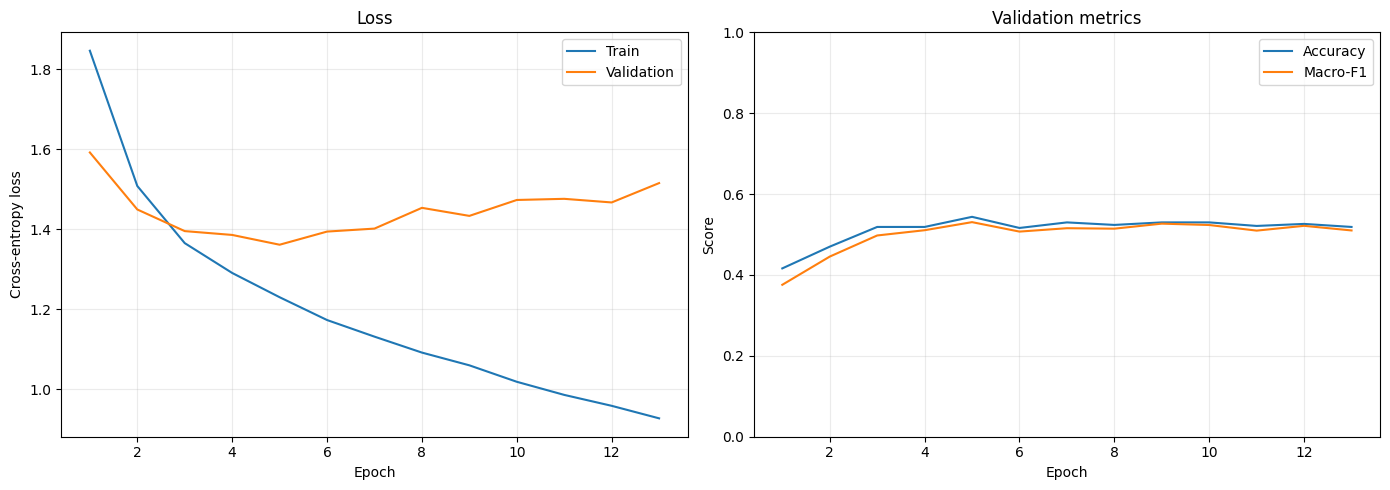

Saved output artifacts:
- fma_class_names.json (0.1 KiB)
- fma_processed_tracks.csv (189.7 KiB)
- task2_gnn_best.pt (333.6 KiB)
- task2_gnn_history.json (2.6 KiB)
- task2_gnn_metrics.json (0.1 KiB)
- task2_gnn_per_class_metrics.csv (0.2 KiB)
- task2_gnn_training_history.png (87.0 KiB)


,genre,f1
0,Hip-Hop,0.659794
1,Rock,0.585366
2,Electronic,0.552036
3,International,0.513089
4,Instrumental,0.396226
5,Pop,0.336957
6,Folk,0.260090
7,Experimental,0.223529


In [9]:
# 13. Evaluate the best model and save artifacts
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])

test_metrics, test_labels, test_preds = evaluate(model, test_loader, criterion, return_arrays=True)
gnn_test_metrics = test_metrics
gnn_history = history
print(f"Best epoch: {checkpoint['epoch']}")
print("Test results")
print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
print(f"  Macro-F1: {test_metrics['macro_f1']:.4f}")
print(f"  Loss:     {test_metrics['loss']:.4f}")

per_class_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0, labels=range(NUM_CLASSES))
per_class_frame = pd.DataFrame({"genre": class_names, "f1": per_class_f1}).sort_values(
    "f1", ascending=False, ignore_index=True
)
per_class_frame.to_csv(OUTPUT_DIR / "task2_gnn_per_class_metrics.csv", index=False)

with (OUTPUT_DIR / "task2_gnn_metrics.json").open("w", encoding="utf-8") as file:
    json.dump(test_metrics, file, indent=2)

history_frame = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_frame["epoch"], history_frame["train_loss"], label="Train")
axes[0].plot(history_frame["epoch"], history_frame["val_loss"], label="Validation")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-entropy loss")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(history_frame["epoch"], history_frame["val_accuracy"], label="Accuracy")
axes[1].plot(history_frame["epoch"], history_frame["val_macro_f1"], label="Macro-F1")
axes[1].set(title="Validation metrics", xlabel="Epoch", ylabel="Score", ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "task2_gnn_training_history.png", dpi=160, bbox_inches="tight")
plt.show()

print("Saved output artifacts:")
for artifact_path in sorted(OUTPUT_DIR.glob("*")):
    if artifact_path.is_file():
        print(f"- {artifact_path.name} ({artifact_path.stat().st_size / 1024:.1f} KiB)")

per_class_frame.head(10)


## CNN baseline on mel-spectrograms

Reference comparison required by the Task 2 spec. The CNN sees the same tracks, the same
official FMA splits, the same class weights and the same optimizer schedule as the GNN —
only the input representation differs (128-bin log-mel spectrogram instead of a segment graph).

In [10]:
# 14. Mel-spectrogram dataset and CNN baseline model
from torch.utils.data import DataLoader as TorchDataLoader


class MelSpectrogramDataset(Dataset):
    def __init__(self, mel_paths, track_ids, labels, mel_mean, mel_std):
        self.mel_paths = mel_paths
        self.track_ids = list(track_ids)
        self.labels = labels
        self.mel_mean = mel_mean
        self.mel_std = mel_std

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, index):
        track_id = self.track_ids[index]
        mel = np.load(self.mel_paths[track_id]).astype(np.float32)
        mel = (mel - self.mel_mean) / self.mel_std
        return torch.from_numpy(mel).unsqueeze(0), torch.tensor(self.labels[track_id], dtype=torch.long)


mel_stat_ids = random.sample(split_ids["train"], min(500, len(split_ids["train"])))
mel_sample = np.stack([np.load(id_to_mel_path[tid]).astype(np.float32) for tid in mel_stat_ids])
MEL_MEAN = float(mel_sample.mean())
MEL_STD = float(mel_sample.std()) or 1.0
del mel_sample
print(f"Mel normalization - mean: {MEL_MEAN:.3f}, std: {MEL_STD:.3f}")


class MelCNN(nn.Module):
    """Four-block VGG-style CNN, the standard mel-spectrogram tagging baseline."""

    def __init__(self, config, num_classes):
        super().__init__()
        blocks = []
        in_channels = 1
        for out_channels in config["channels"]:
            blocks.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(inplace=True),
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(inplace=True),
                    nn.MaxPool2d(2),
                )
            )
            in_channels = out_channels
        self.blocks = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(config["dropout"])
        self.classifier = nn.Linear(in_channels, num_classes)

    def forward(self, spectrogram):
        hidden = self.blocks(spectrogram)
        hidden = self.pool(hidden).flatten(1)
        return self.classifier(self.dropout(hidden))


mel_datasets = {
    name: MelSpectrogramDataset(id_to_mel_path, split_ids[name], track_to_label, MEL_MEAN, MEL_STD)
    for name in ("train", "val", "test")
}
mel_loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "persistent_workers": NUM_WORKERS > 0,
}
mel_train_loader = TorchDataLoader(mel_datasets["train"], shuffle=True, **mel_loader_options)
mel_val_loader = TorchDataLoader(mel_datasets["val"], shuffle=False, **mel_loader_options)
mel_test_loader = TorchDataLoader(mel_datasets["test"], shuffle=False, **mel_loader_options)

print(
    f"Mel batches - train: {len(mel_train_loader):,}, "
    f"validation: {len(mel_val_loader):,}, test: {len(mel_test_loader):,}"
)

Mel normalization - mean: -43.869, std: 16.383
Mel batches - train: 200, validation: 25, test: 25


In [11]:
# 15. Train the CNN baseline (identical optimizer schedule, loss and early stopping as the GNN)
@torch.inference_mode()
def evaluate_cnn(model, loader, loss_function, return_arrays=False):
    model.eval()
    all_labels, all_preds = [], []
    total_loss, total_examples = 0.0, 0

    for spectrograms, targets in tqdm(loader, desc="Evaluating", leave=False):
        spectrograms = spectrograms.to(DEVICE, non_blocking=PIN_MEMORY)
        targets = targets.to(DEVICE, non_blocking=PIN_MEMORY)
        logits = model(spectrograms)
        loss = loss_function(logits, targets)

        total_loss += loss.item() * targets.size(0)
        total_examples += targets.size(0)
        all_preds.append(logits.argmax(dim=-1).cpu().numpy())
        all_labels.append(targets.cpu().numpy())

    labels = np.concatenate(all_labels)
    preds = np.concatenate(all_preds)
    metrics = {
        "loss": float(total_loss / total_examples),
        "accuracy": float(accuracy_score(labels, preds)),
        "macro_f1": float(f1_score(labels, preds, average="macro", zero_division=0)),
    }
    if return_arrays:
        return metrics, labels, preds
    return metrics


cnn_model = MelCNN(CNN_CONFIG, NUM_CLASSES).to(DEVICE)
cnn_optimizer = AdamW(cnn_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
cnn_scheduler = SequentialLR(
    cnn_optimizer,
    schedulers=[
        LinearLR(cnn_optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS),
        CosineAnnealingLR(cnn_optimizer, T_max=EPOCHS - WARMUP_EPOCHS),
    ],
    milestones=[WARMUP_EPOCHS],
)
CNN_CHECKPOINT_PATH = OUTPUT_DIR / "task2_cnn_best.pt"
CNN_HISTORY_PATH = OUTPUT_DIR / "task2_cnn_history.json"

print(f"CNN trainable parameters: {sum(p.numel() for p in cnn_model.parameters() if p.requires_grad):,}")

cnn_history = []
best_cnn_macro_f1 = float("-inf")
cnn_epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    cnn_model.train()
    total_train_loss, total_train_examples = 0.0, 0

    progress = tqdm(mel_train_loader, desc=f"CNN epoch {epoch:02d}/{EPOCHS}")
    for spectrograms, targets in progress:
        spectrograms = spectrograms.to(DEVICE, non_blocking=PIN_MEMORY)
        targets = targets.to(DEVICE, non_blocking=PIN_MEMORY)

        cnn_optimizer.zero_grad(set_to_none=True)
        logits = cnn_model(spectrograms)
        loss = criterion(logits, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cnn_model.parameters(), max_norm=1.0)
        cnn_optimizer.step()

        total_train_loss += loss.item() * targets.size(0)
        total_train_examples += targets.size(0)
        progress.set_postfix(loss=f"{loss.item():.4f}")

    cnn_scheduler.step()
    train_loss = total_train_loss / total_train_examples
    val_metrics = evaluate_cnn(cnn_model, mel_val_loader, criterion)
    cnn_history.append(
        {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "learning_rate": float(cnn_scheduler.get_last_lr()[-1]),
            **{f"val_{name}": value for name, value in val_metrics.items()},
        }
    )

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"accuracy={val_metrics['accuracy']:.4f} | macro_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_cnn_macro_f1:
        best_cnn_macro_f1 = val_metrics["macro_f1"]
        cnn_epochs_without_improvement = 0
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": cnn_model.state_dict(),
                "cnn_config": CNN_CONFIG,
                "num_classes": NUM_CLASSES,
                "class_names": class_names,
                "mel_mean": MEL_MEAN,
                "mel_std": MEL_STD,
            },
            CNN_CHECKPOINT_PATH,
        )
    else:
        cnn_epochs_without_improvement += 1

    with CNN_HISTORY_PATH.open("w", encoding="utf-8") as file:
        json.dump(cnn_history, file, indent=2)

    if cnn_epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping after epoch {epoch}")
        break

print(f"Best CNN validation macro-F1: {best_cnn_macro_f1:.4f}")

CNN trainable parameters: 1,175,656


CNN epoch 01/30:   0%|          | 0/200 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 01 | train_loss=1.6362 | val_loss=1.4880 | accuracy=0.4725 | macro_f1=0.4453


CNN epoch 02/30:   0%|          | 0/200 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 29 | train_loss=0.4792 | val_loss=1.3189 | accuracy=0.5850 | macro_f1=0.5855


CNN epoch 30/30:   0%|          | 0/200 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 30 | train_loss=0.4775 | val_loss=1.3200 | accuracy=0.5938 | macro_f1=0.5913
Best CNN validation macro-F1: 0.5927


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

TASK 2 - TEST RESULTS (FMA-small, official splits)
                model  accuracy  macro_f1     loss
  GNN (segment graph)   0.44375  0.440886 1.598358
CNN (mel-spectrogram)   0.51375  0.511819 1.526333


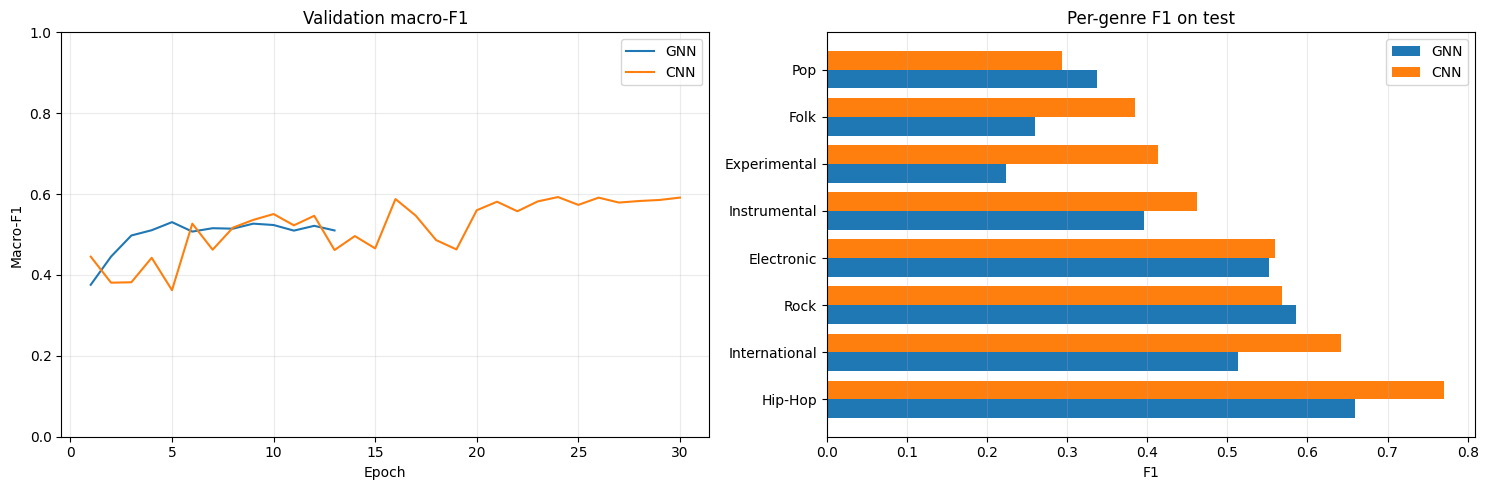

,genre,gnn_f1,cnn_f1
0,Hip-Hop,0.659794,0.770563
1,International,0.513089,0.641711
2,Rock,0.585366,0.567742
3,Electronic,0.552036,0.560000
4,Instrumental,0.396226,0.462312
5,Experimental,0.223529,0.413793
6,Folk,0.260090,0.384314
7,Pop,0.336957,0.294118


In [12]:
# 16. GNN vs. CNN comparison on the held-out test split
cnn_checkpoint = torch.load(CNN_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
cnn_model.load_state_dict(cnn_checkpoint["model_state_dict"])

cnn_test_metrics, cnn_test_labels, cnn_test_preds = evaluate_cnn(
    cnn_model, mel_test_loader, criterion, return_arrays=True
)

comparison_frame = pd.DataFrame(
    [
        {"model": "GNN (segment graph)", **{k: gnn_test_metrics[k] for k in ("accuracy", "macro_f1", "loss")}},
        {"model": "CNN (mel-spectrogram)", **{k: cnn_test_metrics[k] for k in ("accuracy", "macro_f1", "loss")}},
    ]
)
comparison_frame.to_csv(OUTPUT_DIR / "task2_gnn_vs_cnn.csv", index=False)

with (OUTPUT_DIR / "task2_comparison_metrics.json").open("w", encoding="utf-8") as file:
    json.dump({"gnn": gnn_test_metrics, "cnn": cnn_test_metrics}, file, indent=2)

print("=" * 60)
print("TASK 2 - TEST RESULTS (FMA-small, official splits)")
print("=" * 60)
print(comparison_frame.to_string(index=False))
print("=" * 60)

cnn_per_class_f1 = f1_score(
    cnn_test_labels, cnn_test_preds, average=None, zero_division=0, labels=range(NUM_CLASSES)
)
per_class_comparison = pd.DataFrame(
    {"genre": class_names, "gnn_f1": per_class_f1, "cnn_f1": cnn_per_class_f1}
).sort_values("cnn_f1", ascending=False, ignore_index=True)
per_class_comparison.to_csv(OUTPUT_DIR / "task2_per_class_comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cnn_history_frame = pd.DataFrame(cnn_history)
gnn_history_frame = pd.DataFrame(gnn_history)
axes[0].plot(gnn_history_frame["epoch"], gnn_history_frame["val_macro_f1"], label="GNN")
axes[0].plot(cnn_history_frame["epoch"], cnn_history_frame["val_macro_f1"], label="CNN")
axes[0].set(title="Validation macro-F1", xlabel="Epoch", ylabel="Macro-F1", ylim=(0, 1))
axes[0].legend()
axes[0].grid(alpha=0.25)

positions = np.arange(NUM_CLASSES)
axes[1].barh(positions - 0.2, per_class_comparison["gnn_f1"], height=0.4, label="GNN")
axes[1].barh(positions + 0.2, per_class_comparison["cnn_f1"], height=0.4, label="CNN")
axes[1].set_yticks(positions, per_class_comparison["genre"])
axes[1].set(title="Per-genre F1 on test", xlabel="F1")
axes[1].legend()
axes[1].grid(alpha=0.25, axis="x")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "task2_gnn_vs_cnn.png", dpi=160, bbox_inches="tight")
plt.show()

per_class_comparison